In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

sys.path.append(os.path.abspath(".."))

In [5]:
df = pd.read_csv('../data/raw/Metro_Interstate_Traffic_Volume.csv')

Informations générales

In [11]:
print(f"Dimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Colonnes : {list(df.columns)}")

print("Types de données :")
print(df.dtypes)

print("Aperçu des premières lignes :")
print(df.head())

print("Statistiques descriptives :")
print(df.describe())

Dimensions du dataset : 48204 lignes × 9 colonnes
Colonnes : ['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume']
Types de données :
holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object
Aperçu des premières lignes :
  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  
0    scattered clouds  20

Valeurs manquantes

In [41]:
missing = pd.DataFrame({
    'Colonne': df.columns,
    'Nombre_NaN': df.isnull().sum(),
    'Pourcentage_NaN': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Nombre_NaN'] > 0].sort_values('Nombre_NaN', ascending=False)

if len(missing) > 0:
    print("valeurs manquantes détéctées:")
    print(missing.to_string(index=False))
else:
    print("Aucune valeur manquante détectée")

valeurs manquantes détéctées:
Colonne  Nombre_NaN  Pourcentage_NaN
holiday       48143            99.87


Pour faciliter l'utilisation de cette variable dans nos modèles de machine learning, nous avons décidé de transformer cette variable catégorielle en variable binaire : 

0 = Jour normal (pas de jour férié) : Correspond aux valeurs NaN actuelles 
1 = Jour férié : Correspond aux valeurs non-NaN actuelles

valeurs dupliquées

In [63]:
nb_doublons = df.duplicated().sum()
pourcentage_doublons = (nb_doublons / len(df) * 100).round(2)

print(f"Nombre total de lignes : {len(df)}")
print(f"Nombre de doublons : {nb_doublons} ({pourcentage_doublons}%)")

if nb_doublons > 0:
    print(f"{nb_doublons} lignes dupliquées détectées")
    print("\nAperçu des doublons :")
    print(df[df.duplicated(keep=False)].head(10))
else:
    print("Aucun doublon détecté ")

Nombre total de lignes : 48204
Nombre de doublons : 17 (0.04%)
17 lignes dupliquées détectées

Aperçu des doublons :
      holiday     temp  rain_1h  snow_1h  clouds_all weather_main  \
18696     NaN  286.290      0.0      0.0           1        Clear   
18697     NaN  286.290      0.0      0.0           1        Clear   
23850     NaN  289.060      0.0      0.0          90       Clouds   
23851     NaN  289.060      0.0      0.0          90       Clouds   
26783     NaN  289.775      0.0      0.0          56       Clouds   
26784     NaN  289.775      0.0      0.0          56       Clouds   
26979     NaN  287.860      0.0      0.0           0        Clear   
26980     NaN  287.860      0.0      0.0           0        Clear   
27170     NaN  279.287      0.0      0.0          56       Clouds   
27171     NaN  279.287      0.0      0.0          56       Clouds   

      weather_description            date_time  traffic_volume  
18696        sky is clear  2015-09-30 19:00:00            

 Nous supprimons tous les doublons en conservant uniquement la première occurrence de chaque ligne dupliquée

Outliers

In [73]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

outliers_summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    nb_outliers = len(outliers)
    pct_outliers = round(nb_outliers / len(df) * 100, 2)
    
    outliers_summary.append({
        'Variable': col,
        'Q1': Q1,
        'Médiane': df[col].median(),
        'Q3': Q3,
        'IQR': IQR,
        'Limite_Inf': lower_bound,
        'Limite_Sup': upper_bound,
        'Nb_Outliers': nb_outliers,
        'Pct_Outliers': pct_outliers,
        'Min': df[col].min(),
        'Max': df[col].max()
    })

outliers_df = pd.DataFrame(outliers_summary)
print("outliers par variable :")
print(outliers_df.to_string(index=False))



outliers par variable :
      Variable      Q1  Médiane       Q3      IQR  Limite_Inf  Limite_Sup  Nb_Outliers  Pct_Outliers  Min     Max
          temp  272.16   282.45  291.806   19.646     242.691     321.275           10          0.02  0.0  310.07
       rain_1h    0.00     0.00    0.000    0.000       0.000       0.000         3467          7.19  0.0 9831.30
       snow_1h    0.00     0.00    0.000    0.000       0.000       0.000           63          0.13  0.0    0.51
    clouds_all    1.00    64.00   90.000   89.000    -132.500     223.500            0          0.00  0.0  100.00
traffic_volume 1193.00  3380.00 4933.000 3740.000   -4417.000   10543.000            0          0.00  0.0 7280.00


In [79]:
#Affichage des outliers
for col in numerical_cols:
    outliers = df[(df[col] < outliers_df[outliers_df['Variable']==col]['Limite_Inf'].values[0]) | 
                  (df[col] > outliers_df[outliers_df['Variable']==col]['Limite_Sup'].values[0])][col]
    
    if len(outliers) > 0:
        print(f"\n{col}:")
        print(sorted(outliers.unique()))


temp:
[0.0]

rain_1h:
[0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6, 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.7, 0.71, 0.72, 0.73, 0.74, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 1.0, 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1, 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.19, 1.2, 1.21, 1.22, 1.24, 1.25, 1.27, 1.28, 1.29, 1.3, 1.31, 1.32, 1.33, 1.34, 1.35, 1.37, 1.38, 1.39, 1.4, 1.41, 1.44, 1.45, 1.46, 1.47, 1.49, 1.5, 1.51, 1.52, 1.53, 1.55, 1.56, 1.59, 1.6, 1.61, 1.63, 1.65, 1.66, 1.67, 1.68, 1.69, 1.7, 1.71, 1.72, 1.76, 1.78, 1.8, 1.82, 1.83, 1.84, 1.85, 1.86, 1.87, 1.88, 1.9, 1.91, 1.93, 1.95, 1.96, 1.98, 2.03, 2.05, 2.06, 2.08, 2.1, 2.11, 2.12, 2.13, 2.14, 2.15, 2.16, 2.18, 2.19, 2.2, 2.21, 2.22, 2.26, 2.29, 2.31, 2.33,

Outliers Détectés et Interprétation :

Temperature (10 outliers) :
L'analyse a détecté 10 valeurs de température égales à 0 Kelvin (-273°C).Cette température est physiquement impossible sur Terre. Ces 10 lignes doivent être supprimées du dataset car elles fausseraient nos modèles de prédiction.

Pluie - rain_1h (3467 outliers) :
La méthode IQR a identifié 3467 outliers pour la variable rain_1h, avec des valeurs allant de 0.25mm à 55mm (et une valeur extrême de 9831.3mm). Ces valeurs sont détectées comme aberrantes car 95% du temps il ne pleut pas (rain_1h = 0), ce qui rend toute valeur de pluie statistiquement rare. Cependant, des valeurs entre 0.25mm et 55mm sont parfaitement normales pour de la pluie légère à modérée et doivent être conservées. Seule la valeur de 9831.3mm est physiquement impossible et doit être supprimée.

Neige - snow_1h (63 outliers) :
La situation est identique pour la neige ; 63 outliers ont été détectés avec des valeurs entre 0.05mm et 0.51mm. Ces valeurs correspondent à de la neige légère, ce qui est tout à fait normal en hiver à Minneapolis. Elles sont marquées comme outliers uniquement parce que la neige est rare présente seulement quelques jours par an, mais ces valeurs sont réelles et doivent être conservées dans notre dataset.

à supprimer : Les 10 lignes avec temp = 0.0 et la ligne avec rain_1h = 9831.3mm 

Matrice de Corrélation

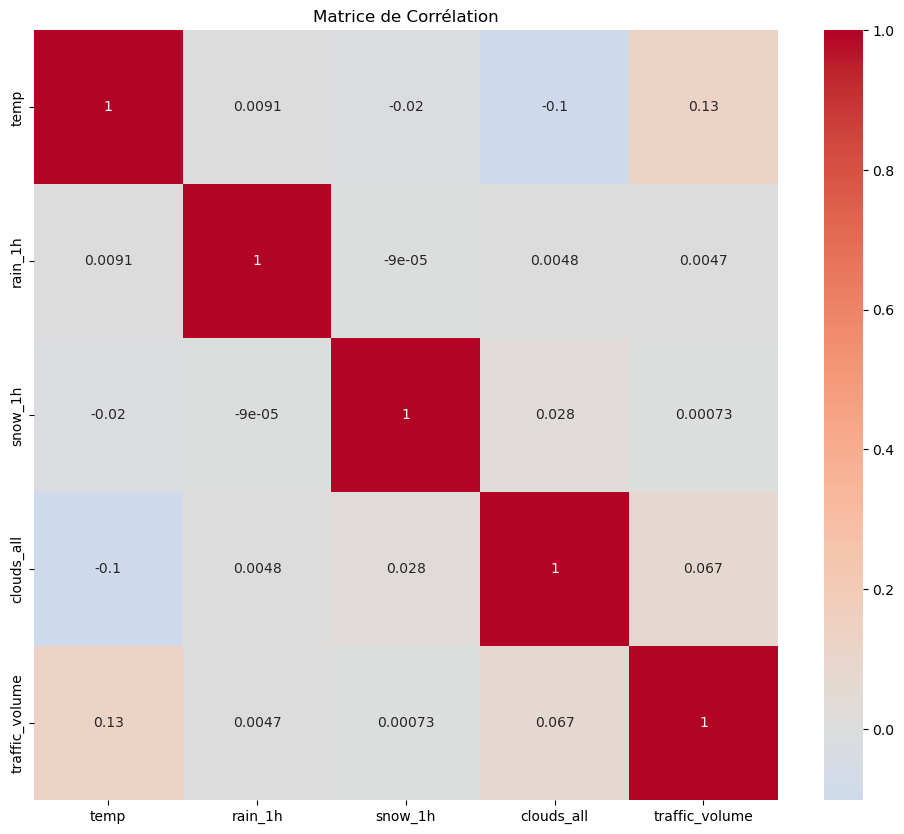

In [81]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de Corrélation')
plt.show()

Trafic par jour de la semaine 

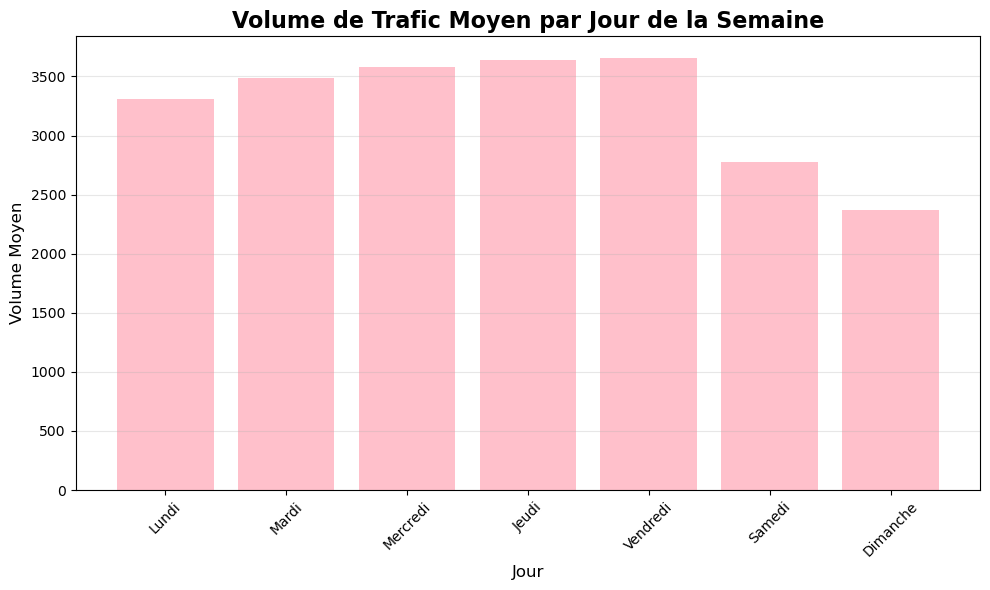

In [83]:
df['date_time'] = pd.to_datetime(df['date_time'])
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month
df['year'] = df['date_time'].dt.year

plt.figure(figsize=(10,6))
jours = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
trafic_par_jour = df.groupby('day_of_week')['traffic_volume'].mean()
plt.bar(range(7), trafic_par_jour.values, color='pink')
plt.xticks(range(7), jours, rotation=45)
plt.title('Volume de Trafic Moyen par Jour de la Semaine', fontsize=16, fontweight='bold')
plt.xlabel('Jour', fontsize=12)
plt.ylabel('Volume Moyen', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

 Trafic par  heure

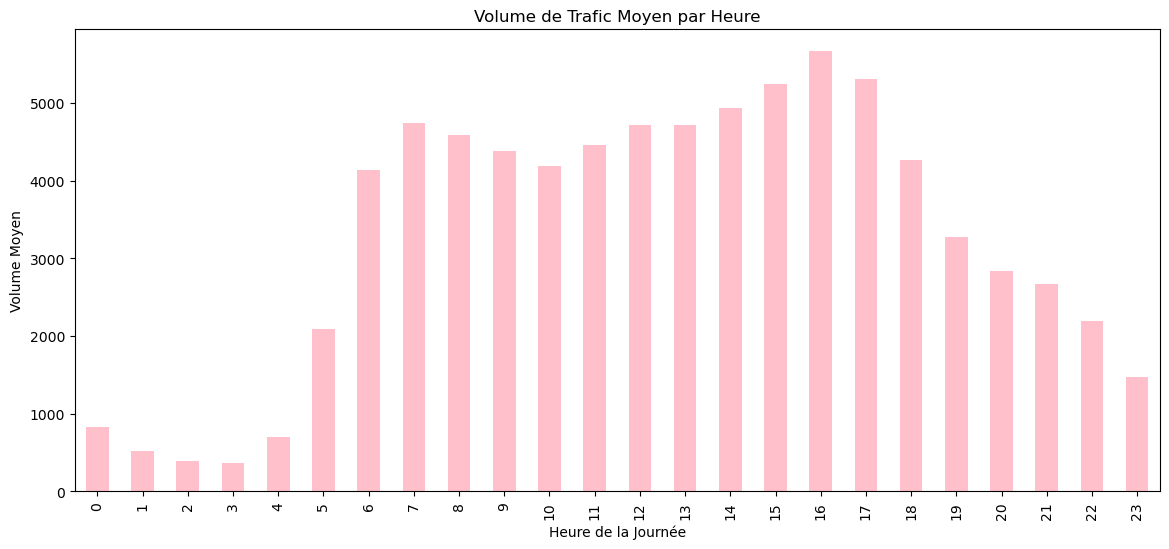

In [85]:
plt.figure(figsize=(14,6))
df.groupby('hour')['traffic_volume'].mean().plot(kind='bar',color="pink")

plt.title('Volume de Trafic Moyen par Heure')
plt.xlabel('Heure de la Journée')
plt.ylabel('Volume Moyen')
plt.show()

Traffic par mois

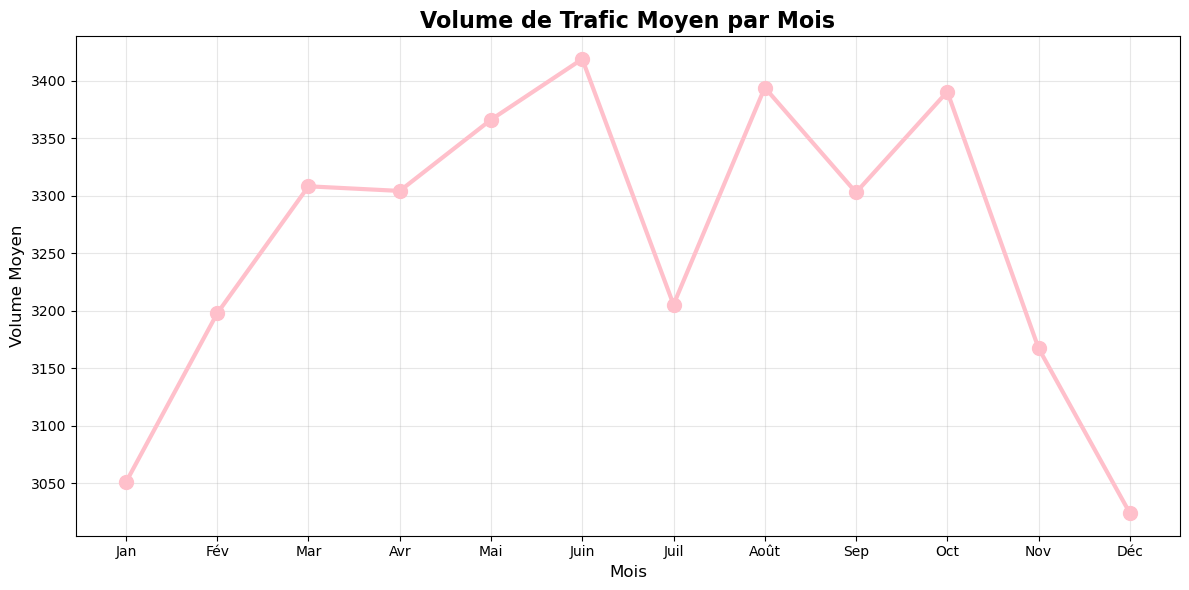

In [95]:
plt.figure(figsize=(12,6))
mois = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']
trafic_par_mois = df.groupby('month')['traffic_volume'].mean()
plt.plot(range(1, 13), trafic_par_mois.values, marker='o', linewidth=3, markersize=10, color='pink')
plt.xticks(range(1, 13), mois)
plt.title('Volume de Trafic Moyen par Mois', fontsize=16, fontweight='bold')
plt.xlabel('Mois', fontsize=12)
plt.ylabel('Volume Moyen', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Impact jours fériés

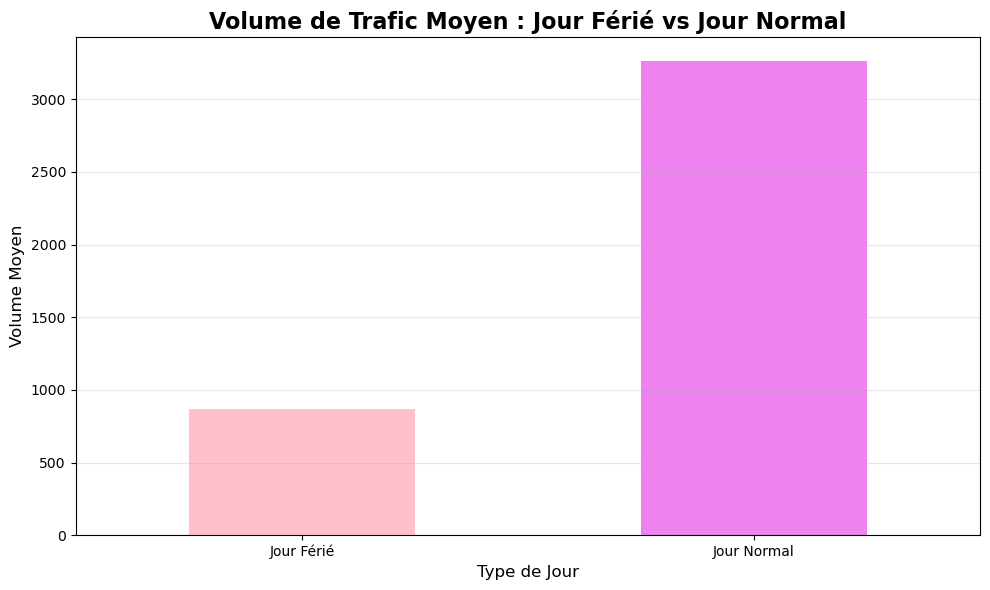

In [101]:
plt.figure(figsize=(10,6))
df['is_holiday'] = df['holiday'].apply(lambda x: 'Jour Férié' if pd.notna(x) and x != 'None' else 'Jour Normal')
df.groupby('is_holiday')['traffic_volume'].mean().plot(kind='bar', color=['pink', 'violet'])
plt.title('Volume de Trafic Moyen : Jour Férié vs Jour Normal', fontsize=16, fontweight='bold')
plt.xlabel('Type de Jour', fontsize=12)
plt.ylabel('Volume Moyen', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Impact météo

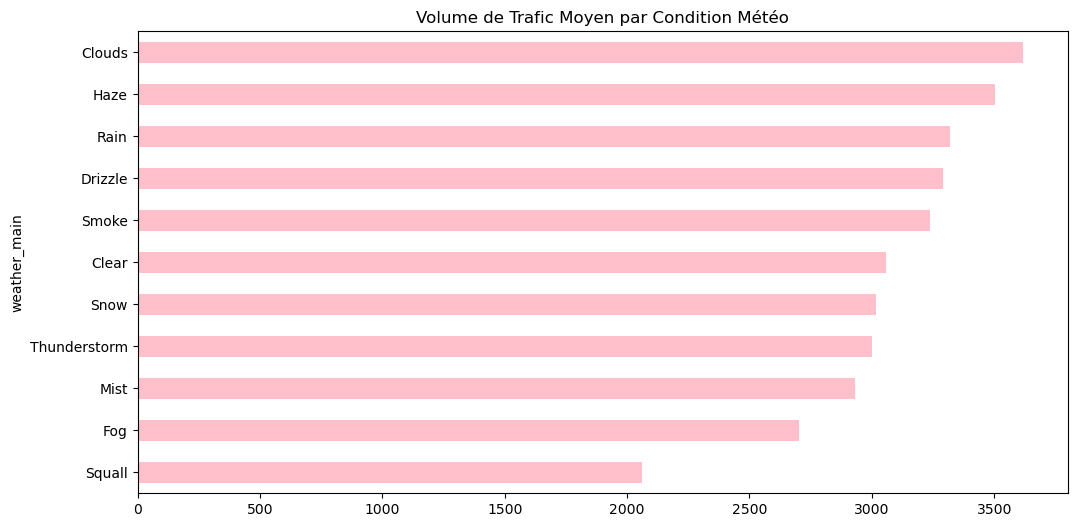

In [103]:
plt.figure(figsize=(12,6))
df.groupby('weather_main')['traffic_volume'].mean().sort_values().plot(kind='barh',color='pink')
plt.title('Volume de Trafic Moyen par Condition Météo')
plt.show()